<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

## Setup

Install non-optional packages:

In [24]:
!pip install wandb datasets tsilva_notebook_utils==0.0.29

🔑 Loading API keys and authentication tokens from Colab secrets:

In [25]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

Define configuration:

In [26]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed for reproducibility
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID
    #dataset_id = "tsilva/GymnasiumRecording__SuperMarioBros_Nes"  # @param {type: "string"}
    dataset_id = "tsilva/GymnasiumRecording__Tetris_GameBoy" # @param {type: "string"}

    # @markdown
    frame_stack_size = 1  # @param {type: "number"}

    # @markdown How many frames to skip
    frame_skip = 4 # @param {type: "number"}

    image_scale = 0.5  # @param {type: "number"}
    image_mode = "grayscale"  # @param ["color", "grayscale", "black_and_white"]
    image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    sparsity_loss_alpha = 0.01  # @param {type: "number"}

    # @markdown Noise factor for input corruption
    noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Latent space dimensionality
    latent_dim = 32  # @param {type: "number"}

    latent_noise_factor = 0.1  # @param {type: "number"}
    validation_epochs = 10  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Batch size
    batch_size = 1024  # @param {type: "integer"}

    # @markdown Gradient clipping norm (0 = disabled)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown Weight decay for regularization
    weight_decay = 0  # @param {type: "number"}

    # @markdown Warmup ratio for learning rate scheduler
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use
    loss_function = "mse"

    # @markdown Learning rate for the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    #os.environ["NOTEBOOK_ID"] = notebook_id_from_title()
    os.environ["NOTEBOOK_ID"] = "notebook123"

    return dict(
        # Notebook settings
        seed=seed,

        validation_epochs=validation_epochs,

        sparsity_loss_alpha=sparsity_loss_alpha,
        # Dataset
        dataset_id=dataset_id,
        frame_skip=frame_skip,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        image_mode=image_mode,
        image_crop_paddings=image_crop_paddings,
        noise_factor=noise_factor,

        # Model
        latent_dim=latent_dim,
        latent_noise_factor=latent_noise_factor,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate
    )

CONFIG = setup_config()

In [27]:
#import torch
#torch.backends.cudnn.benchmark = True

In [28]:
from wandb import login
WANDB_API_KEY = os.getenv("WANDB_API_KEY"); assert WANDB_API_KEY is not None, "WANDB_API_KEY environment variable is not set"
login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

Load dataset:

In [29]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")
dataset_list = list(dataset)
dataset

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 10308
})

Show sample dataset image:

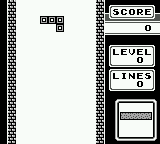

In [30]:
sample_image = dataset[0]["image"]
sample_image

Convert image to grayscale:

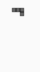

In [31]:
import torch
import multiprocessing
from torchvision.transforms.functional import to_tensor, to_pil_image, resize
from PIL import Image

def process_image_batch(images):
    # Preload config so we only access CONFIG once
    mode = CONFIG.get("image_mode", "color")
    scale = CONFIG.get("image_scale", 1.0)
    paddings = CONFIG.get("image_crop_paddings")
    noise_factor = CONFIG.get("noise_factor", 0.0)

    processed = []
    for image in images:
        # Convert mode
        if mode == "color":
            image = image.convert("RGB")
        elif mode == "grayscale":
            image = image.convert("L")
        elif mode == "black_and_white":
            image = image.convert("1")
        else:
            raise ValueError(f"Unsupported color mode: {mode}")

        # Crop if needed
        if paddings:
            padding = [int(x) for x in paddings.split(",")]
            width, height = image.size
            left = padding[3]
            top = padding[0]
            right = width - padding[1]
            bottom = height - padding[2]
            image = image.crop((left, top, right, bottom))

        # Convert to tensor
        image_ts = to_tensor(image)

        # Resize
        if scale != 1.0:
            _, h, w = image_ts.shape
            new_h, new_w = int(h * scale), int(w * scale)
            image_ts = resize(image_ts, [new_h, new_w])

        # Noise
        if noise_factor:
            noise = torch.randn_like(image_ts) * noise_factor
            image_ts = torch.clamp(image_ts + noise, 0.0, 1.0)

        image_ts = image_ts.to(torch.float16)
        processed.append(image_ts)

    return processed

processed_image_t = process_image_batch([sample_image])[0]
processed_image = to_pil_image(processed_image_t)
processed_image

Retrieve dataset image dimensions:

In [32]:
n_channels, image_height, image_width = processed_image_t.shape
n_channels, image_height, image_width

(1, 72, 40)

Let's process dataset to ensure it has configured transformations (eg: grayscaling and image noise):

In [33]:
def _map_batch(batch):
    inputs = batch["image"]
    inputs = process_image_batch(inputs)
    targets = inputs
    return dict(
        input=inputs,
        target=targets
    )

processed_dataset = dataset.map(
    _map_batch,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/10308 [00:00<?, ? examples/s]

Create frame collator that takes frame stacking into account:

In [34]:
from torch.utils.data import DataLoader

test_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step', 'action'])
test_dataset = test_dataset.with_format("torch")  # or "numpy" or "pandas"
#test_dataset = test_dataset.map(lambda x: x)  # forces full load

#list(test_dataset)
frame_skip = CONFIG['frame_skip']
mask = torch.arange(len(test_dataset)) % frame_skip == 0  # True for train
train_dataset = test_dataset.select(torch.nonzero(mask).squeeze()).with_format("torch")
val_dataset = test_dataset.select(torch.nonzero(~mask).squeeze()).with_format("torch")

# In the DataLoader creation section:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(), # Or experiment with other values
    persistent_workers=True, # Add this
    prefetch_factor=4 # Add this, experiment with values like 2, 4, 8
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(), # Or experiment
    persistent_workers=True, # Add this
    prefetch_factor=4 # Add this
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(), # Or experiment
    persistent_workers=True, # Add this
    prefetch_factor=4 # Add this
)

In [35]:
from tsilva_notebook_utils.video import render_loader_video
render_loader_video(val_loader)

Rendering frames: 100%|██████████| 8/8 [00:05<00:00,  1.42it/s]


Create the model:

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None, use_fc=True):
        super(ConvAutoencoder, self).__init__()

        if latent_dim is None: latent_dim = CONFIG['latent_dim']
        self.use_fc = use_fc

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_fc:
            self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
            self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_fc:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_fc:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        self._encoded = z

        # Add noise to latent space
        # TODO: disable during inference
        if CONFIG['latent_noise_factor']: # TODO: move to init
          noise = torch.randn_like(z) * CONFIG['latent_noise_factor']
          z = z + noise

        out = self.decode(z)
        return out

use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG["frame_stack_size"] * n_channels, n_channels, image_height, image_width, use_fc=use_fc)
model

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=5760, out_features=32, bias=True)
  (fc_dec): Linear(in_features=32, out_features=5760, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Create model, loss function and optimizer:

In [37]:
from tsilva_notebook_utils.torch import get_current_device

device = get_current_device()
use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG['frame_stack_size'] * n_channels, n_channels, image_height, image_width, use_fc=use_fc).to(device)
model = torch.compile(model, mode="max-autotune")

if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=n_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"], fused=True)

Test a forward pass through the model to make sure shapes are accurate:

In [38]:
model.eval()
for batch in train_loader:
    #batch = batch.to(device)
    x, y = batch["input"], batch["target"]
    x = x.to(device)
    y = y.to(device)
    print(x.shape)
    print(y.shape)
    assert torch.equal(x, y), "Input and target tensors are not the same"
    with torch.no_grad(): y_pred = model(x)
    print(y_pred.shape)
    loss = loss_fn(y_pred, y)
    print(loss.item())
    break

torch.Size([1024, 1, 72, 40])
torch.Size([1024, 1, 72, 40])


AUTOTUNE addmm(1024x5760, 1024x32, 32x5760)
  bias_addmm 0.1239 ms 100.0% 
  addmm 0.1628 ms 76.1% 
SingleProcess AUTOTUNE benchmarking takes 0.2238 seconds and 0.0004 seconds precompiling for 2 choices
AUTOTUNE addmm(1024x32, 1024x5760, 5760x32)
  bias_addmm 0.1608 ms 100.0% 
  addmm 0.1618 ms 99.4% 
SingleProcess AUTOTUNE benchmarking takes 0.2203 seconds and 0.0003 seconds precompiling for 2 choices


torch.Size([1024, 1, 72, 40])
0.24286168813705444


Run training:

In [39]:
import wandb
from tqdm import tqdm
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tsilva_notebook_utils.torch import calc_model_grad_norms

# Iterate over batches
from torch import autocast, GradScaler

# TODO: is calculating grad norms slow?
def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID"); assert NOTEBOOK_ID is not None, "NOTEBOOK_ID environment variable is not set"
    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        if n_epochs is None: n_epochs = CONFIG['n_epochs']
        if learning_rate is None: learning_rate = CONFIG['learning_rate']
        if max_grad_norm is None: max_grad_norm = CONFIG['max_grad_norm']
        if warmup_ratio is None: warmup_ratio = CONFIG['warmup_ratio']

        scaler = GradScaler('cuda')

        # Set model to training mode
        #model.train()

        # Watch model for gradient logging with wandb
        wandb.watch(model, log="all")

        # Linear warmup schedule: linearly increase LR for warmup_steps, then keep constant
        total_steps = n_epochs * len(train_loader)
        warmup_steps = int(warmup_ratio * total_steps) if warmup_ratio else 0
        def lr_lambda(current_step): return float(current_step) / float(max(1, warmup_steps)) if current_step < warmup_steps else 1.0
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

        # Progress bar for training
        global_step = 0
        device = next(model.parameters()).device
        with tqdm(range(n_epochs), desc="Training") as pbar:
            for epoch in pbar:
                losses, accuracies, grad_norms, latent_sparsities, layer_norms = [], [], [], [], {}
                last_layer_norms = {}

                model.train()
                for batch in train_loader:
                    x_batch, y_batch = batch["input"], batch["target"]
                    x_batch = x_batch.to(device)
                    y_batch = y_batch.to(device)

                    global_step += 1

                    optimizer.zero_grad()

                    with autocast('cuda'):
                        # Forward pass
                        logits = model(x_batch)

                        # Calculate loss
                        reconstruction_loss = loss_fn(logits, y_batch)
                        if CONFIG['sparsity_loss_alpha'] > 0.0:
                            sparsity_loss = CONFIG['sparsity_loss_alpha'] * torch.mean(torch.abs(model._encoded))
                            loss = reconstruction_loss + sparsity_loss
                        else:
                            loss = reconstruction_loss

                        losses.append(loss.item())

                    scaler.scale(loss).backward()
                    if max_grad_norm:
                        scaler.unscale_(optimizer)
                        clip_grad_norm_(model.parameters(), max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()

                    # Perform learning rate scheduler step
                    scheduler.step()

                    # Perform backpropagation
                    #loss.backward()

                    # Optionally clip gradients to avoid exploding gradients
                    #if max_grad_norm: clip_grad_norm_(model.parameters(), max_grad_norm)

                    # Calculate gradient norms for monitoring
                    #_grad_norm, _layer_norms = calc_model_grad_norms(model)
                    #grad_norms.append(_grad_norm)

                    #last_layer_norms = layer_norms

                    # Perform optimization step
                    #optimizer.step()

                    # Calculate latent sparsity with threshold
                    with torch.no_grad():
                        threshold = 1e-3  # You can adjust this value as needed
                        encoded = model._encoded
                        num_elements = encoded.numel()
                        num_zeros = torch.sum(torch.abs(encoded) < threshold).item()
                        latent_sparsity = num_zeros / num_elements
                        #print(latent_sparsity)
                        latent_sparsities.append(latent_sparsity)

                    #print(f"Sparsity: {sparsity:.4f} ({sparsity * 100:.2f}%)")

                    # Calculate training accuracy
                    #with torch.no_grad():
                    #    predicted = torch.argmax(logits, dim=1)
                    #    accuracy = (predicted == y_batch).float().mean().item()
                    #    accuracies.append(accuracy)

                if epoch % CONFIG['validation_epochs'] == 0:
                    model.eval()
                    val_losses = []
                    for batch in val_loader:
                        x_batch, y_batch = batch["input"], batch["target"]
                        x_batch = x_batch.to(device)
                        y_batch = y_batch.to(device)
                        with torch.no_grad():
                            logits = model(x_batch)
                            reconstruction_loss = loss_fn(logits, y_batch)
                            val_losses.append(reconstruction_loss.item())
                    val_loss = sum(val_losses) / len(val_losses)

                # Log W&B stats
                train_loss = sum(losses) / len(losses)
                latent_sparsity = sum(latent_sparsities) / len(latent_sparsities)
                #train_accuracy = sum(accuracies) / len(accuracies)
                #train_grad_norm = sum(grad_norms) / len(grad_norms)
                current_lr = scheduler.get_last_lr()[0]
                wandb_stats = {
                    'meta/epoch': epoch + 1,
                    'meta/step': global_step,
                    'meta/learning_rate': current_lr,

                    'train/loss': train_loss,
                    'train/reconstruction_loss': reconstruction_loss.item(),
                    'train/sparsity_loss': sparsity_loss.item(),
                    'train/latent_sparsity' : latent_sparsity,
                    'val/loss' : val_loss,
                    #'train/accuracy': train_accuracy,

                    #'grad/total_norm': train_grad_norm,
                }
                #for _layer_name, _layer_norm in _layer_norms.items(): wandb_stats[f'grad/layer/{_layer_name}'] = _layer_norm

                pbar_stats = {
                    'epoch': epoch + 1,
                    'train_loss': f'{train_loss:.4f}',
                    'lr': f'{current_lr:.6e}',
                    #'grad_norm': f'{train_grad_norm:.2f}',
                    #'train_acc': f'{train_accuracy * 100:.2f}%'
                }

                # Run evaluation on validation set
                if eval_fn:
                    result = eval_fn()
                    val_loss = result['loss']
                    val_accuracy = result['accuracy']
                    wandb_stats['val/loss'] = val_loss
                    wandb_stats['val/accuracy'] = val_accuracy
                    pbar_stats['val_acc'] =  f'{val_accuracy * 100:.2f}%'

                # Log stats to w-andb
                wandb.log(wandb_stats, step=global_step)

                # Show key metrics in progress bar
                pbar.set_postfix(pbar_stats)

                # Early stopping if training accuracy hits 100%
                #if train_accuracy == 1.0:
                #    print("\nTraining finished early: model perfectly fit the training set.")
                #    break

        return run

train(model, loss_fn, optimizer, train_loader)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]AUTOTUNE addmm(1024x5760, 1024x32, 32x5760)
  bias_addmm 0.0788 ms 100.0% 
  addmm 0.0850 ms 92.8% 
SingleProcess AUTOTUNE benchmarking takes 0.2371 seconds and 0.0003 seconds precompiling for 2 choices
AUTOTUNE addmm(1024x32, 1024x5760, 5760x32)
  bias_addmm 0.0809 ms 100.0% 
  addmm 0.0809 ms 100.0% 
SingleProcess AUTOTUNE benchmarking takes 0.2179 seconds and 0.0003 seconds precompiling for 2 choices
AUTOTUNE addmm(529x32, 529x5760, 5760x32)
  bias_addmm 0.0502 ms 100.0% 
  addmm 0.0522 ms 96.1% 
SingleProcess AUTOTUNE benchmarking takes 0.2186 seconds and 0.0003 seconds precompiling for 2 choices
AUTOTUNE addmm(529x5760, 529x32, 32x5760)
  bias_addmm 0.0481 ms 100.0% 
  addmm 0.0532 ms 90.4% 
SingleProcess AUTOTUNE benchmarking takes 0.2166 seconds and 0.0004 seconds precompiling for 2 choices
AUTOTUNE addmm(563x32, 563x5760, 5760x32)
  bias_addmm 0.0952 ms 100.0% 
  addmm 0.0963 ms 98.9% 
SingleProcess AUTOTUNE benchmarking takes 0

meta/epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇█
meta/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meta/step,▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/latent_sparsity,▆▄▁▁▁█▆▇▄▃▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▅▅▆▆▆▅▆▆▆
train/loss,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/reconstruction_loss,█▇▆▅▅▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/sparsity_loss,▁▃█▆▄▃▃▃▃▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
val/loss,██▅▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meta/epoch,324
meta/learning_rate,0.001
meta/step,972


KeyboardInterrupt: 

In [40]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(latent_dim):
        encoded = torch.zeros(latent_dim, device=device)
        encoded[i] = 1.0
        encoded = encoded.unsqueeze(0)  # shape: (1, latent_dim)
        decoded = model.decode(encoded)
        frames.append(decoded.squeeze())
    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10)
video

Saving frames: 100%|██████████| 32/32 [00:00<00:00, 3094.21it/s]


In [41]:
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir
import torch.nn.functional as F
import random

latent_dim = CONFIG['latent_dim']
sparsity_ratio = 0.05  # Match your model's average sparsity
num_frames = latent_dim  # or choose more/less depending on what you want to visualize

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for _ in range(num_frames):
        # Start with all zeros
        encoded = torch.zeros(latent_dim, device=device)

        # Randomly activate a sparse subset
        n_active = int(latent_dim * sparsity_ratio)
        active_indices = random.sample(range(latent_dim), n_active)

        # Assign random values (or fixed if you want consistency)
        encoded[active_indices] = torch.rand(n_active, device=device)

        # Decode and save frame
        decoded = model.decode(encoded.unsqueeze(0))
        frame = decoded.squeeze().detach().cpu()
        frames.append(frame)

    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10)

video

Saving frames: 100%|██████████| 32/32 [00:00<00:00, 3923.69it/s]


Render video of autoencoder predictions:

In [43]:
from tsilva_notebook_utils.video import render_autoencoder_video
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(), # Or experiment
)
CONFIG['latent_noise_factor'] = 0.0 # TODO: remove this
render_autoencoder_video(model, val_loader)

Saving temporary frames to: /tmp/tmppobjkfiu


Processing batches: 100%|██████████| 8/8 [00:16<00:00,  2.09s/it]


Rendering video from 7731 frames...
Video rendering complete.


⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()